Motivation: in the poster project, I mentioned the idea of clustering lyrics. 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 16,
    "axes.titlesize": 20,
    "legend.fontsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

drop_punc = lambda s: re.sub(r"[^A-Za-z']+", " ", s).strip()

In the original project, the following albums were analysed:
* Taylor Swift
* Fearless
* Speak Now
* Red
* 1989
* Reputation
* Lover
* folklore
* evermore
* Midnights
* The Tortured Poets Department + Anthology
* All Taylor's Version albums
* Live versions of songs listed above
* Speak Now World Tour Live - but the accessible data for this album is not good.

Using the data we have available, we should analyse Taylor Swift, all Taylor's Version albums, Reputation, Lover, folklore, evermore, Midnights and TTPD, using deluxe versions wherever possible.

In [3]:
import os

# THE FOLLOWING FUNCTION WAS WRITTEN BY GEN AI
def clean_text(text):
    # split into lines and drop first line
    lines = text.splitlines()[1:]
    text = " ".join(lines)
    text = re.sub(r"\d+Embed", "", text)

    # remove apostrophe
    text = re.sub(r"'", "", text)
    # remove square bracket content
    text = re.sub(r"\[.*?\]", "", text)

    # keep letters, numbers and whitespace
    text = re.sub(r"[^A-Za-z0-9\s]+", " ", text)

    # normalise whitespace
    text = re.sub(r"\s+", " ", text).strip()
    return text

genfolder = '/kaggle/input/datasets/ishikajohari/taylor-swift-all-lyrics-30-albums/data/Albums/'
folders = ['TaylorSwift', 
           'Fearless_TaylorsVersion_', 
           'SpeakNow_TaylorsVersion_',
           'Red_TaylorsVersion_',
           '1989_TaylorsVersion_',
           'Reputation',
           'Lover',
           'Folklore',
           'Evermore',
           'Midnights_TheTilDawnEdition_',
           'THETORTUREDPOETSDEPARTMENT_THEANTHOLOGY']
corpus = []
for folder in folders:
    for filename in sorted(os.listdir(genfolder+folder)):
        if filename.endswith(".txt"):
            filepath = os.path.join(genfolder+folder, filename)
    
            with open(filepath, "r", encoding="utf-8") as f:
                corpus.append(clean_text(f.read()))
len(corpus)

240

In [4]:
WCSS = []
silhouette = []
vectoriser = TfidfVectorizer(stop_words="english", min_df=2, max_df=0.9, max_features=5000)
X = vectoriser.fit_transform(corpus)
len(vectoriser.vocabulary_)

2113

3 clusters are chosen due to contextual knowledge.

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans.fit(X)
Counter(kmeans.labels_)

Counter({np.int32(1): 72, np.int32(2): 108, np.int32(0): 60})

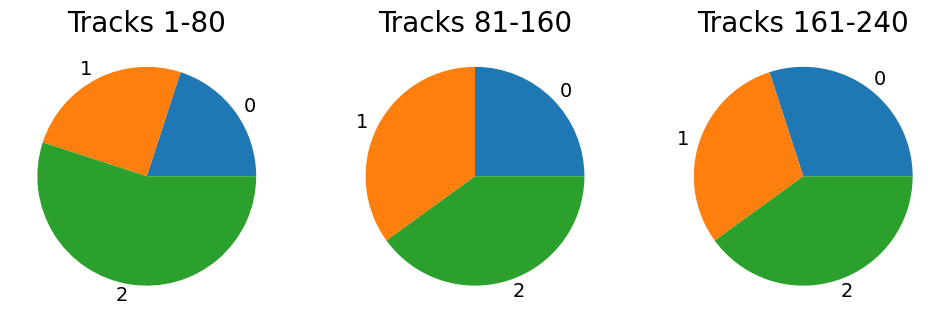

In [6]:
tflabels = kmeans.labels_
pt1, pt2, pt3= Counter(tflabels[:80]), Counter(tflabels[80:160]), Counter(tflabels[160:])
fig, ax = plt.subplots(ncols=3, figsize=(12, 4))
ax[0].pie([pt1[0], pt1[1], pt1[2]], labels=[0, 1, 2])
ax[0].set_title('Tracks 1-80')
ax[1].pie([pt2[0], pt2[1], pt2[2]], labels=[0, 1, 2])
ax[1].set_title('Tracks 81-160')
ax[2].pie([pt3[0], pt3[1], pt3[2]], labels=[0, 1, 2])
ax[2].set_title('Tracks 161-240')
plt.show()

A Sentence Transformer can also be applied. This is a pretrained model which preserves meaning in the embeddings, rather than just a measure of the word importances.

In [7]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-mpnet-base-v2")

embeddings = model.encode(corpus, normalize_embeddings=True)

kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
labels = kmeans.fit_predict(embeddings)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [8]:
Counter(labels)

Counter({np.int32(1): 84, np.int32(2): 75, np.int32(0): 81})

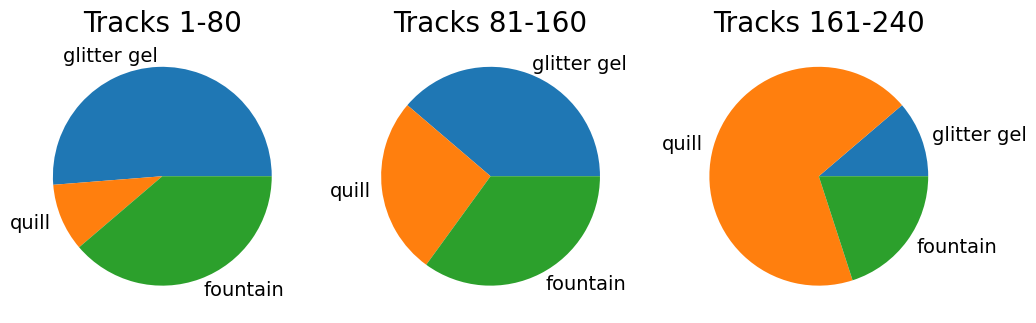

In [9]:
pt1, pt2, pt3= Counter(labels[:80]), Counter(labels[80:160]), Counter(labels[160:])
fig, ax = plt.subplots(ncols=3, figsize=(12, 4))
clusternames = ['glitter gel', 'quill', 'fountain']
ax[0].pie([pt1[0], pt1[1], pt1[2]], labels=clusternames)
ax[0].set_title('Tracks 1-80')
ax[1].pie([pt2[0], pt2[1], pt2[2]], labels=clusternames)
ax[1].set_title('Tracks 81-160')
ax[2].pie([pt3[0], pt3[1], pt3[2]], labels=clusternames)
ax[2].set_title('Tracks 161-240')
plt.savefig('pies.pdf', bbox_inches='tight')
plt.show()

This makes sense - her lyric writing will become more mature as she grows, leading to an increase in cluster 1.

I think 0 is glitter gel pen, 1 is quill, 2 is fountain pen - by inspecting a sample of songs.

In [10]:
songs = []
genfolder = '/kaggle/input/datasets/ishikajohari/taylor-swift-all-lyrics-30-albums/data/Albums/'
folders = ['TaylorSwift', 
           'Fearless_TaylorsVersion_', 
           'SpeakNow_TaylorsVersion_',
           'Red_TaylorsVersion_',
           '1989_TaylorsVersion_',
           'Reputation',
           'Lover',
           'Folklore',
           'Evermore',
           'Midnights_TheTilDawnEdition_',
           'THETORTUREDPOETSDEPARTMENT_THEANTHOLOGY']
corpus = []
for folder in folders:
    for song in sorted(os.listdir(genfolder + folder)):
        songs.append(song.split('.')[0])


In [11]:
clusters = pd.DataFrame({'song': songs, 'STcluster': labels, 'TFcluster': tflabels})

centroids = []
for c in np.unique(labels):
    centroids.append(
        embeddings[labels == c].mean(axis=0)
    )

clusters[clusters['song'].isin(['peace', 'Gorgeous', 'Labyrinth'])]

,song,STcluster,TFcluster
125,Gorgeous,0,2
166,peace,1,2
195,Labyrinth,2,2


Now this can be used as a feature in clustering the songs.

In [12]:
clusters.to_csv('lyric_clusters.csv', index=False)